# Introduction

Stock price prediction is an obvious application for data analysis and modelling. Having an accurate idea as to the price of a given stock at any point informs the buyer as to whether or not a purchase of that stock at the time is advisable. Furthermore, modelling might well allow for predictions in future trends of the price of the stock, allowing one to make much more informed decisions regarding their investment portfolio. The most popular methods of modelling stock prices tend to involve deep learning models such as LSTM (long short-term memory) and machine learning. This notebook will attempt to build a model based on a "hybrid" approach that can then be used to predict the closing stock price of a given company; Apple Inc. (stock symbol AAPL) has been used as an example for the notebook only.

# Modelling Approach

## ARIMA

The approach to modelling stock prices will combine several methods and techniques from time series analysis, statistical modelling and machine learning. The first model used is the ARIMA (Autoregressive Integrated Moving Average) model, which is applied to the log returns of the stock price data. The autoregression (AR) component uses past values to predict future values. The differencing (I) component makes the data stationary (i.e. constant mean and variance) by subtracting the previous observation. The moving average (MA) component models the relationship between an observation and a residual error from a moving average model applied to lagged observations. In this case, it is used to model the log returns of the stock in question and get the residuals, which serve as an input to the GARCH model.<sup>1</sup>

## GARCH

The purpose GARCH (Generalized Autoregressive Conditional Heteroskedasticity) is to model the volatility, or variability, in stock returns over time. In this case, the GARCH model is fitted to the residuals of the ARIMA model to estimate volatility for the next 365 days. The volatility estimate produced by the GARCH model is then combined with ARIMA.<sup>1</sup>

## Ridge Regression



[*********************100%***********************]  1 of 1 completed


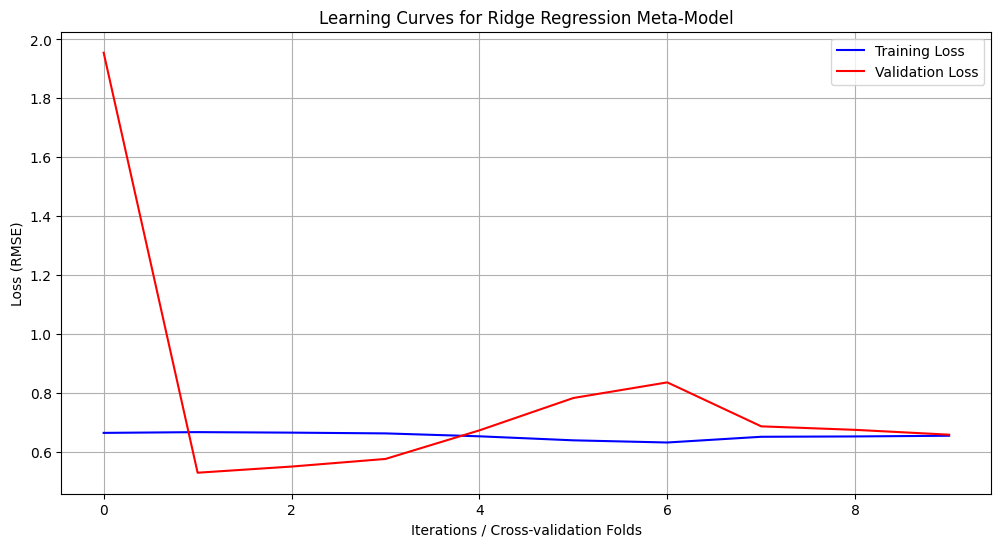

Train RMSE: 0.6543
Test RMSE: 0.7356
Train MAE: 0.5014
Test MAE: 0.5677
Train R²: 0.9978
Test R²: 0.9974


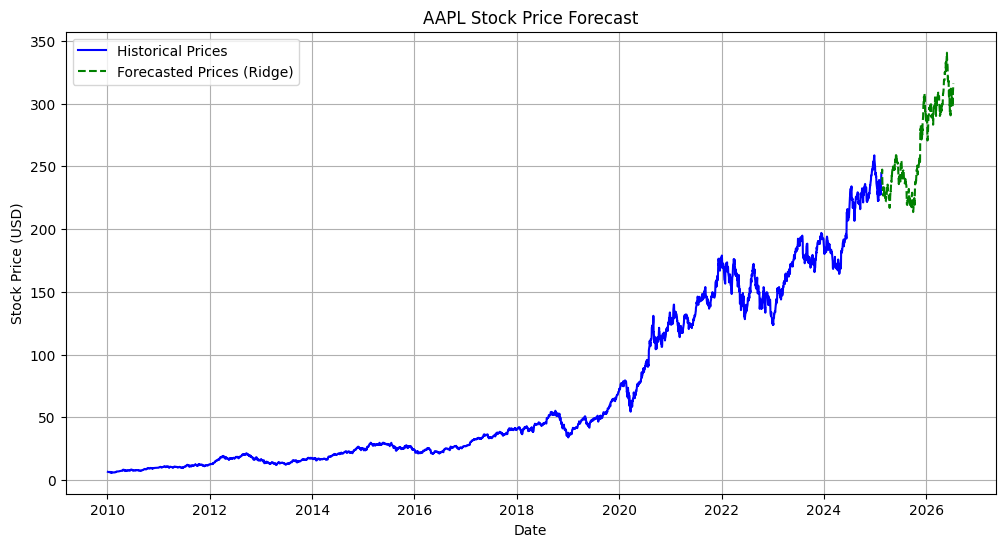

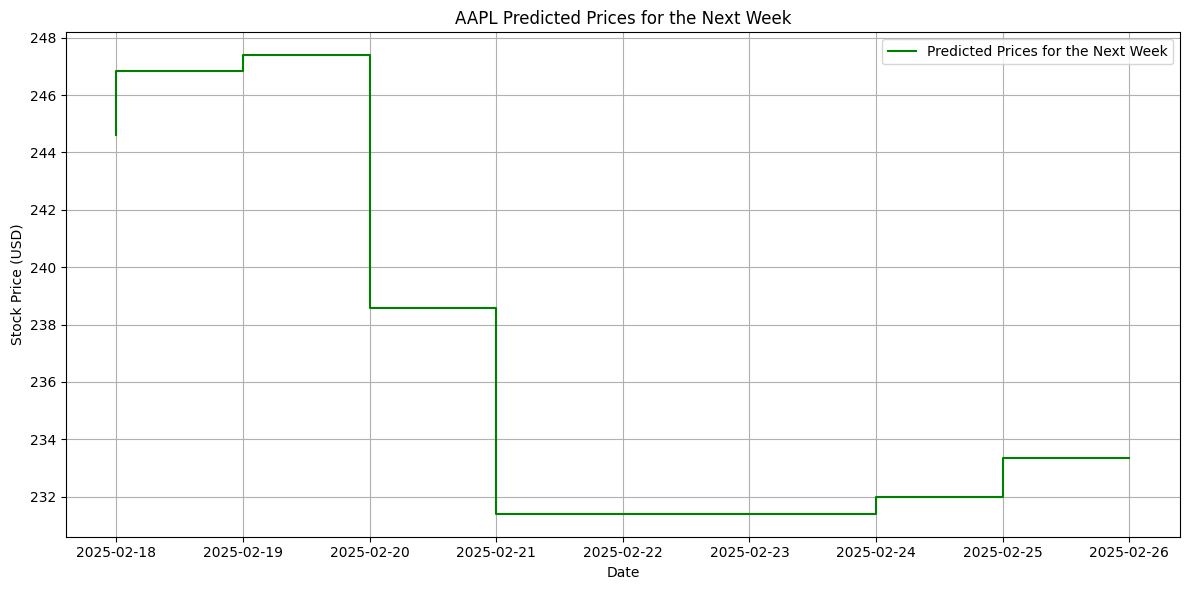

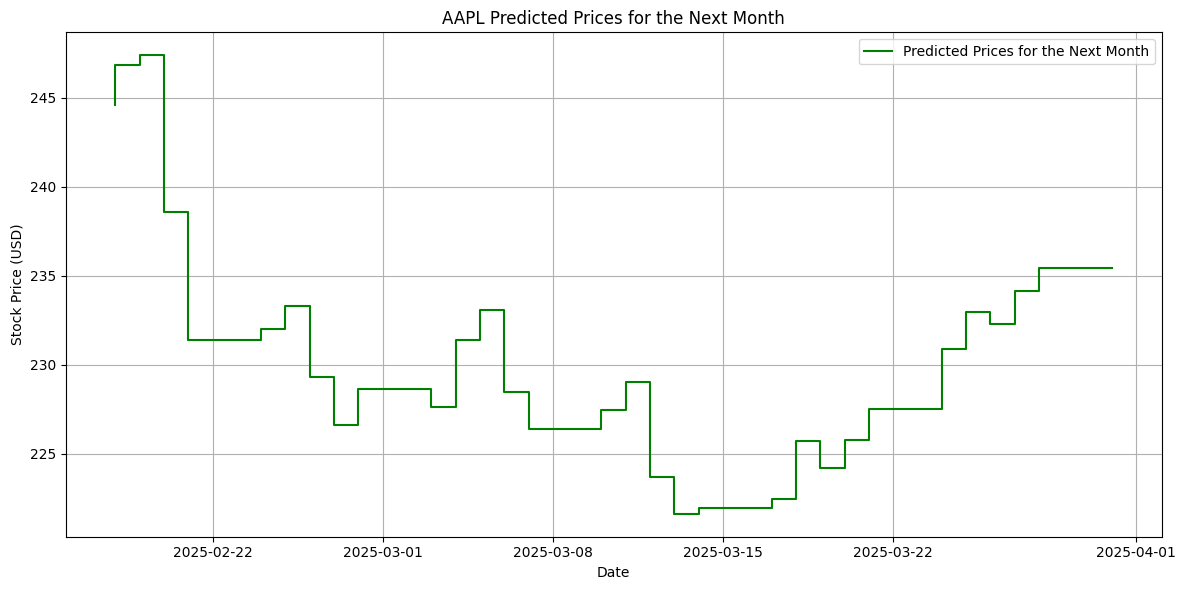

In [32]:
import datetime
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

# Suppress warnings
warnings.filterwarnings("ignore")

# Download stock data
stock_symbol = 'AAPL'
data = yf.download(stock_symbol, start='2010-01-01', end=datetime.date.today().strftime('%Y-%m-%d'))
data['Log_Ret'] = np.log(data['Close'] / data['Close'].shift(1))
data = data.dropna()

# Fit ARIMA model to the log returns
log_returns = data['Log_Ret']
arima_model = ARIMA(log_returns, order=(5, 0, 0))
arima_result = arima_model.fit()

# ARIMA Residuals
arima_residuals = arima_result.resid

# Fit GARCH model to the residuals of the ARIMA model
garch_model = arch_model(arima_residuals, vol='Garch', p=1, q=1)
garch_result = garch_model.fit(disp="off")

# Forecast GARCH volatility for the next 365 days
garch_forecast = garch_result.forecast(horizon=365)
garch_volatility = np.sqrt(garch_forecast.variance.iloc[-1]).values

# Prepare features for Ridge Regression (ARIMA residuals and GARCH volatility)
features = pd.DataFrame({
    'ARIMA_Residuals': arima_residuals[-365:],  # Last 365 residuals
    'GARCH_Volatility': garch_volatility
})

target = log_returns[-365:] * 1000  # Scale target to match the length of features
features = features[np.isfinite(target)]
target = target[np.isfinite(target)]

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, shuffle=False)

# Normalize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize Ridge regression model
ridge_model = RidgeCV(store_cv_values=True)

# Train the Ridge regression model on the scaled training data
ridge_model.fit(X_train_scaled, y_train)

# Predict on training and testing data
train_pred = ridge_model.predict(X_train_scaled)
test_pred = ridge_model.predict(X_test_scaled)

# ---- Learning Curves ----
train_losses = []
val_losses = []

# Track the training and validation losses for early stopping
n_folds = 10  # Cross-validation folds
fold_size = len(X_train) // n_folds

for fold in range(n_folds):
    # Split into training and validation sets
    val_start = fold * fold_size
    val_end = (fold + 1) * fold_size
    train_indices = list(set(range(len(X_train))) - set(range(val_start, val_end)))
    
    # Train the model on the current fold
    X_train_fold, y_train_fold = X_train_scaled[train_indices], y_train[train_indices]
    ridge_model.fit(X_train_fold, y_train_fold)
    
    # Validate on the validation fold
    val_pred = ridge_model.predict(X_train_scaled[val_start:val_end])
    
    # Calculate RMSE for training and validation sets
    train_loss = np.sqrt(mean_squared_error(y_train_fold, ridge_model.predict(X_train_fold)))
    val_loss = np.sqrt(mean_squared_error(y_train[val_start:val_end], val_pred))
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)

# Plot learning curves for Ridge regression
plt.figure(figsize=(12, 6))
plt.plot(train_losses, label='Training Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='red')
plt.title('Learning Curves for Ridge Regression Meta-Model')
plt.xlabel('Iterations / Cross-validation Folds')
plt.ylabel('Loss (RMSE)')
plt.legend()
plt.grid(True)
plt.show()

# ---- Performance Metrics ----
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
train_mae = mean_absolute_error(y_train, train_pred)
test_mae = mean_absolute_error(y_test, test_pred)
train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

# Display performance metrics
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Train MAE: {train_mae:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Train R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")

# ---- Forecasting ----
# Simulate future stock prices for the next 365 days
forecast_dates = pd.date_range(start=datetime.date.today() + pd.Timedelta(days=1), periods=365, freq='B')

# Simulate predicted returns using the Ridge model
future_features = pd.DataFrame({
    'ARIMA_Residuals': arima_residuals[-365:],  # Using the past 365 residuals
    'GARCH_Volatility': garch_volatility
})
future_features_scaled = scaler.transform(future_features)

# Predict future returns using the trained Ridge regression model
future_returns = ridge_model.predict(future_features_scaled)

# Simulate stock prices for the next 365 days
simulated_prices = np.zeros(365)
simulated_prices[0] = data['Close'].iloc[-1]

for i in range(1, len(future_returns)):
    simulated_prices[i] = simulated_prices[i - 1] * np.exp(future_returns[i - 1] / 1000)

# Create a DataFrame for the forecasted prices
forecast_df = pd.DataFrame({'Date': forecast_dates, 'Forecasted_Price': simulated_prices})

# Plot the historical and forecasted prices
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Close'], label='Historical Prices', color='blue')
plt.plot(forecast_df['Date'], forecast_df['Forecasted_Price'], label='Forecasted Prices (Ridge)', color='green', linestyle='--')
plt.title(f'{stock_symbol} Stock Price Forecast')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

# Step Chart for Next 7 Days Predictions
forecast_week = forecast_df.head(7)
plt.figure(figsize=(12, 6))
plt.step(forecast_week['Date'], forecast_week['Forecasted_Price'], label='Predicted Prices for the Next Week', color='green')
plt.title(f'{stock_symbol} Predicted Prices for the Next Week')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Step Chart for Next 30 Days Predictions
forecast_month = forecast_df.head(30)
plt.figure(figsize=(12, 6))
plt.step(forecast_month['Date'], forecast_month['Forecasted_Price'], label='Predicted Prices for the Next Month', color='green')
plt.title(f'{stock_symbol} Predicted Prices for the Next Month')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Analysis

## Learning Curves Plot

## Stock Price Forecast

## Step Charts

The final two plots are step charts, reflecting the up-to-date, predicted prices of AAPL for the week and month, respectively. They may be useful in confirming the model's performance against real-world data, despite being rather basic in appearance.

# Conclusion

This notebook has adequately demonstrated the effectiveness of a "hybrid" approach in modelling stock closing prices, using those of AAPL purely as an example, all with the intention of making the final prediction of stock prices more accurate. Caution should, of course, be taken in interpreting long-term results, as there are any number of unpredictable factors that contribute to the volatility of stock closing prices. Nonetheless, modelling (when correctly applied) can help to take some of the uncertainty out of the equation and may be quite helpful for potential buyers, using the massive amounts of free data available to make smarter purchasing decisions.

# References

<sup>1</sup> - OpenAI. (2025). ChatGPT (February 10 version) [Large language model]. https://chat.openai.com/chat